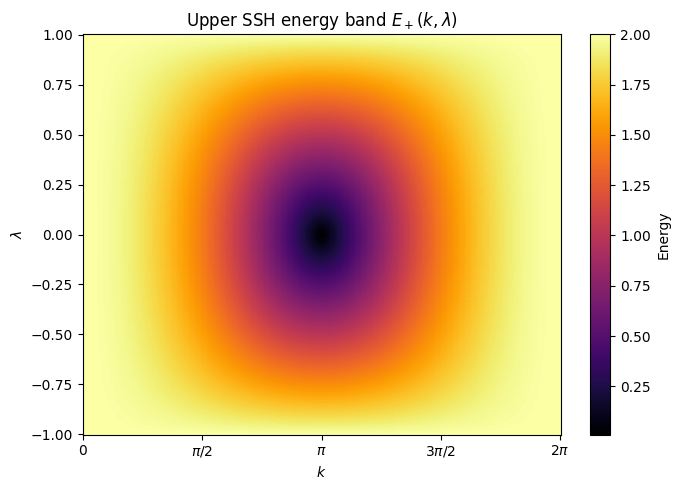

<Figure size 600x500 with 0 Axes>

<Figure size 600x500 with 0 Axes>

In [1]:

import numpy as np
import matplotlib.pyplot as plt

# k and lambda grids
k = np.linspace(0, 2*np.pi, 400)
lam = np.linspace(-1, 1, 400)

K, L = np.meshgrid(k, lam)

# define energy band
t1 = 1 + L
t2 = 1 - L

E = np.sqrt(t1**2 + t2**2 + 2*t1*t2*np.cos(K))  # upper band

plt.figure(figsize=(7,5))
plt.pcolormesh(K, L, E, shading='auto', cmap='inferno')

plt.xlabel(r"$k$")
plt.ylabel(r"$\lambda$")
plt.title(r"Upper SSH energy band $E_+(k,\lambda)$")

# ---- Fix the k-axis ticks to show -π, 0, π ---- #
plt.xticks(
    ticks=[0, np.pi/2, np.pi, 3*np.pi/2, 2*np.pi],
    labels=[r"$0$", r"$\pi/2$", r"$\pi$", r"$3\pi/2$", r"$2\pi$"]
)

plt.colorbar(label="Energy")
plt.tight_layout()
plt.show()
plt.figure(figsize=(6,5))



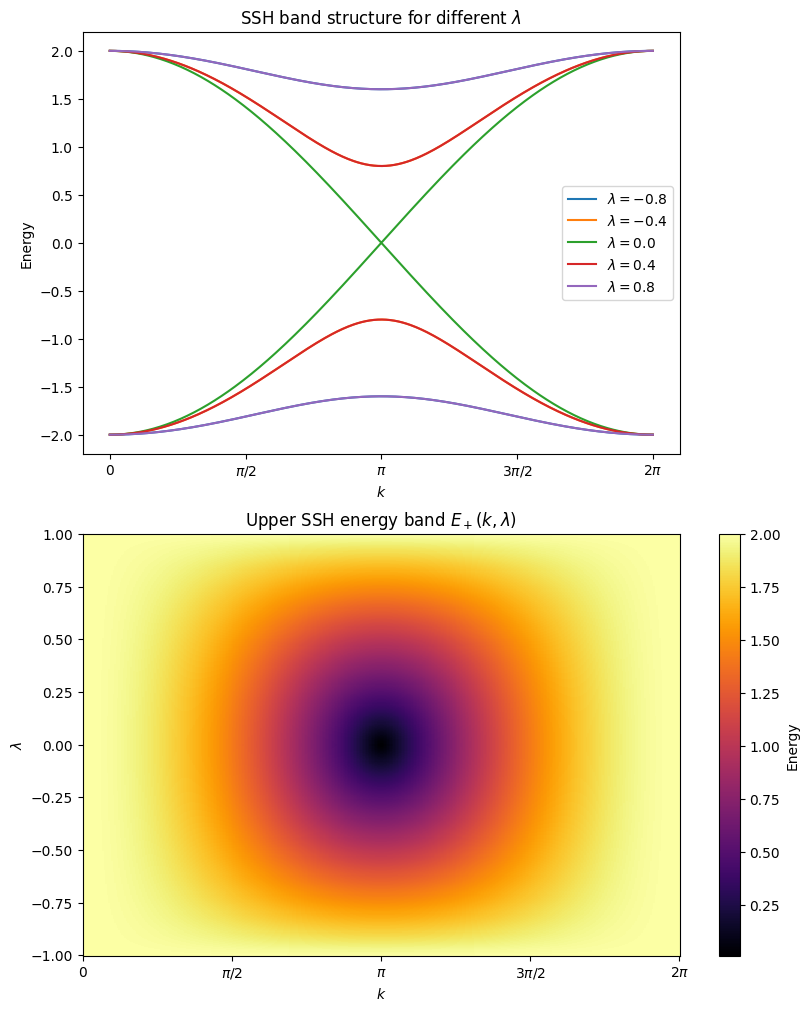

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# Data
# -----------------------------
k = np.linspace(0, 2*np.pi, 400)

def E_band(k, lam):
    t1 = 1 + lam
    t2 = 1 - lam
    return np.sqrt(t1**2 + t2**2 + 2*t1*t2*np.cos(k))

lams = [ -0.8, -0.4, 0.0, 0.4, 0.8 ]

# grids for 2D plot
lam_grid = np.linspace(-1, 1, 400)
K, L = np.meshgrid(k, lam_grid)

t1 = 1 + L
t2 = 1 - L
E2D = np.sqrt(t1**2 + t2**2 + 2*t1*t2*np.cos(K))

# -----------------------------
# Figure with subplots
# -----------------------------
fig, axes = plt.subplots(
    nrows=2,
    ncols=1,
    figsize=(8,10),
    constrained_layout=True
)

# ==========
# Subplot 1: Band structure for fixed lambdas
# ==========
ax1 = axes[0]

for lam in lams:
    Ek = E_band(k, lam)
    ax1.plot(k,  Ek, label=rf"$\lambda={lam}$")
    ax1.plot(k, -Ek, color=ax1.lines[-1].get_color())

ax1.set_xlabel(r"$k$")
ax1.set_ylabel("Energy")
ax1.set_title("SSH band structure for different $\\lambda$")
ax1.legend()

ax1.set_xticks(
    [0, np.pi/2, np.pi, 3*np.pi/2, 2*np.pi]
)
ax1.set_xticklabels(
    [r"$0$", r"$\pi/2$", r"$\pi$", r"$3\pi/2$", r"$2\pi$"]
)

# ==========
# Subplot 2: Upper band as function of (k, lambda)
# ==========
ax2 = axes[1]

pcm = ax2.pcolormesh(
    K, L, E2D,
    shading='auto',
    cmap='inferno'
)

ax2.set_xlabel(r"$k$")
ax2.set_ylabel(r"$\lambda$")
ax2.set_title(r"Upper SSH energy band $E_+(k,\lambda)$")

ax2.set_xticks(
    [0, np.pi/2, np.pi, 3*np.pi/2, 2*np.pi]
)
ax2.set_xticklabels(
    [r"$0$", r"$\pi/2$", r"$\pi$", r"$3\pi/2$", r"$2\pi$"]
)

fig.colorbar(pcm, ax=ax2, label="Energy")

plt.show()